# サッカー選手分析

## 仮説
シュート数が多い選手ほどゴール数が多いのではないか。
また、FWは他ポジションよりゴール数が多いのではないか。

In [1]:
import pandas as pd

df = pd.read_csv("dataset - 2020-09-24.csv")
df.head()

,Name,Jersey Number,Club,Position,Nationality,Age,Appearances,Wins,Losses,Goals,...,Punches,High Claims,Catches,Sweeper clearances,Throw outs,Goal Kicks,Yellow cards,Red cards,Fouls,Offsides
0,Bernd Leno,1.0,Arsenal,Goalkeeper,Germany,28.0,64,28,16,0,...,34.0,26.0,17.0,28.0,375.0,489.0,2,0,0,NaN
1,Matt Macey,33.0,Arsenal,Goalkeeper,England,26.0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,NaN
2,Rúnar Alex Rúnarsson,13.0,Arsenal,Goalkeeper,Iceland,25.0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,NaN
3,Héctor Bellerín,2.0,Arsenal,Defender,Spain,25.0,160,90,37,7,...,NaN,NaN,NaN,NaN,NaN,NaN,23,0,125,8.0
4,Kieran Tierney,3.0,Arsenal,Defender,Scotland,23.0,16,7,5,1,...,NaN,NaN,NaN,NaN,NaN,NaN,2,0,9,0.0


In [2]:
df.columns

Index(['Name', 'Jersey Number', 'Club', 'Position', 'Nationality', 'Age',
       'Appearances', 'Wins', 'Losses', 'Goals', 'Goals per match',
       'Headed goals', 'Goals with right foot', 'Goals with left foot',
       'Penalties scored', 'Freekicks scored', 'Shots', 'Shots on target',
       'Shooting accuracy %', 'Hit woodwork', 'Big chances missed',
       'Clean sheets', 'Goals conceded', 'Tackles', 'Tackle success %',
       'Last man tackles', 'Blocked shots', 'Interceptions', 'Clearances',
       'Headed Clearance', 'Clearances off line', 'Recoveries', 'Duels won',
       'Duels lost', 'Successful 50/50s', 'Aerial battles won',
       'Aerial battles lost', 'Own goals', 'Errors leading to goal', 'Assists',
       'Passes', 'Passes per match', 'Big chances created', 'Crosses',
       'Cross accuracy %', 'Through balls', 'Accurate long balls', 'Saves',
       'Penalties saved', 'Punches', 'High Claims', 'Catches',
       'Sweeper clearances', 'Throw outs', 'Goal Kicks', 'Yellow 

In [3]:
df[["Shots", "Goals"]].corr()

,Shots,Goals
Shots,1.000000,0.931487
Goals,0.931487,1.000000


In [4]:
df["shots_bin"] = pd.cut(df["Shots"], bins=5)
df.groupby("shots_bin")["Goals"].mean()

/tmp/ipykernel_9767/4153776670.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("shots_bin")["Goals"].mean()


,Goals
shots_bin,
"(-0.996, 199.2]",4.040000
"(199.2, 398.4]",31.690476
"(398.4, 597.6]",65.923077
"(597.6, 796.8]",93.333333
"(796.8, 996.0]",180.000000


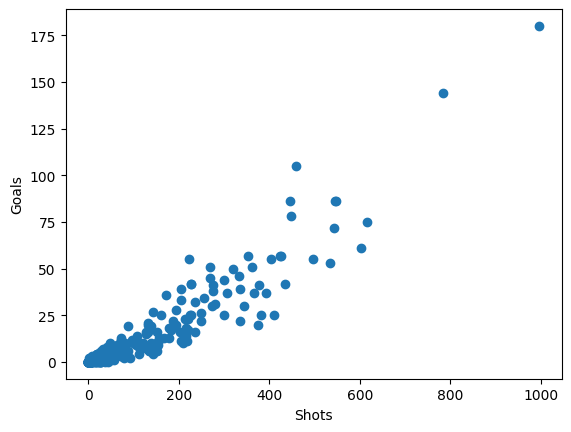

In [5]:
import matplotlib.pyplot as plt

plt.scatter(df["Shots"], df["Goals"])
plt.xlabel("Shots")
plt.ylabel("Goals")
plt.show()

In [6]:
df.groupby("Position")["Goals"].mean()

,Goals
Position,
Defender,2.659794
Forward,21.481818
Goalkeeper,0.000000
Midfielder,6.590909


In [7]:
df.groupby("Position")["Goals"].agg(["mean", "count"])

,mean,count
Position,,
Defender,2.659794,194
Forward,21.481818,110
Goalkeeper,0.000000,69
Midfielder,6.590909,198


In [8]:
df.groupby("Position")["Goals"].agg(["mean","median","count"])

,mean,median,count
Position,,,
Defender,2.659794,1.0,194
Forward,21.481818,6.0,110
Goalkeeper,0.000000,0.0,69
Midfielder,6.590909,2.0,198


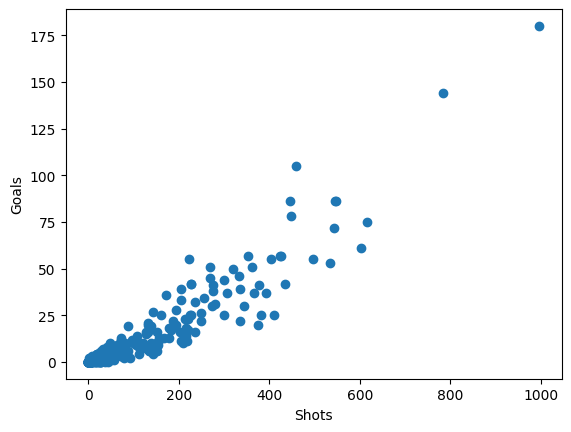

In [9]:
import matplotlib.pyplot as plt   # ①準備

plt.scatter(df["Shots"], df["Goals"])   # ②グラフ作る

plt.xlabel("Shots")   # ③横軸
plt.ylabel("Goals")   # ③縦軸

plt.show()   # ④表示

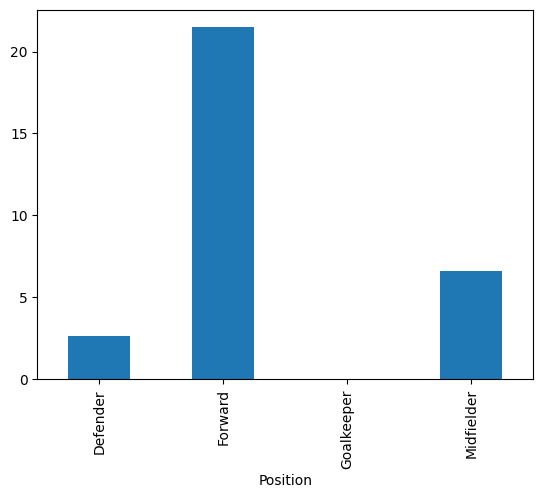

In [10]:
df.groupby("Position")["Goals"].mean().plot(kind="bar")
plt.show()

In [11]:
df[["Shots","Goals"]].corr()

,Shots,Goals
Shots,1.000000,0.931487
Goals,0.931487,1.000000


シュートとゴールには強い相関が見られた
これより、シュートを多く打つ人はゴール数も多い傾向にあると考えられる

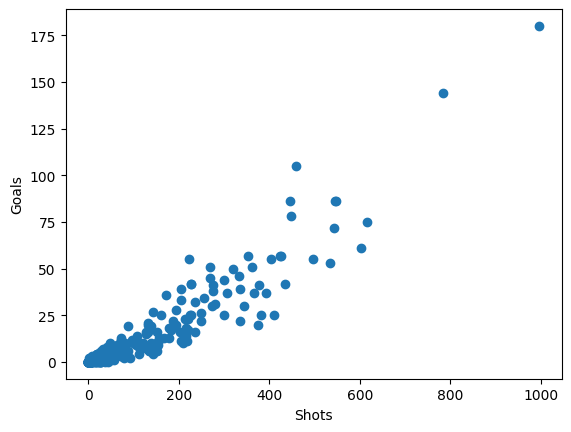

In [12]:
plt.scatter(df["Shots"],df["Goals"])
plt.xlabel("Shots")
plt.ylabel("Goals")
plt.show()

In [13]:
df.groupby("Position")["Goals"].agg(["mean","median","count"])

,mean,median,count
Position,,,
Defender,2.659794,1.0,194
Forward,21.481818,6.0,110
Goalkeeper,0.000000,0.0,69
Midfielder,6.590909,2.0,198


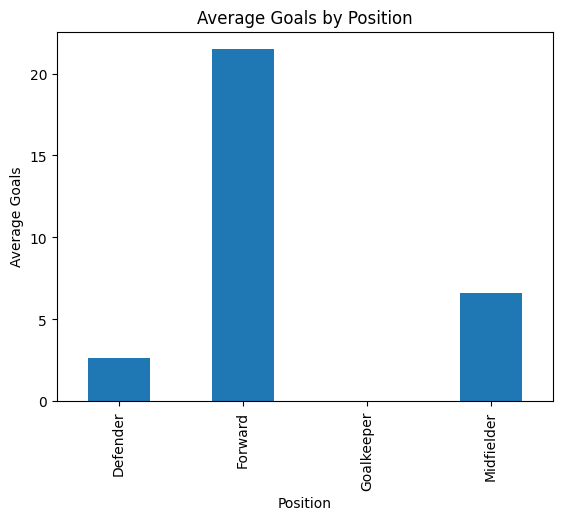

In [14]:
df.groupby("Position")["Goals"].mean().plot(kind="bar")

plt.xlabel("Position")
plt.ylabel("Average Goals")
plt.title("Average Goals by Position")

plt.show()

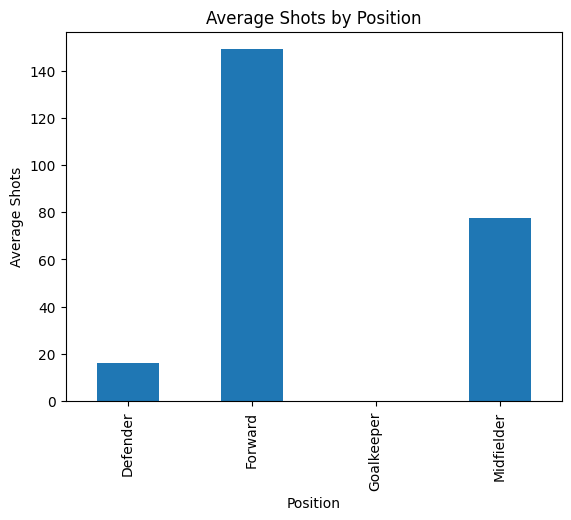

In [15]:
df.groupby("Position")["Shots"].mean().plot(kind="bar")

plt.xlabel("Position")
plt.ylabel("Average Shots")
plt.title("Average Shots by Position")

plt.show()

In [16]:
df["Position"].value_counts()

,count
Position,
Midfielder,198
Defender,194
Forward,110
Goalkeeper,69


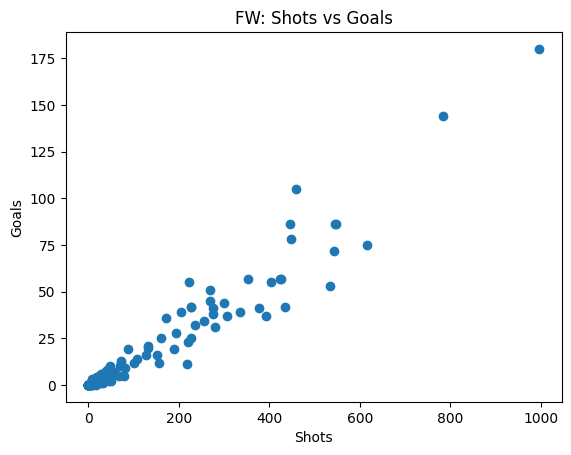

In [17]:
fw = df[df["Position"] == "Forward"]

plt.scatter(fw["Shots"], fw["Goals"])

plt.xlabel("Shots")
plt.ylabel("Goals")
plt.title("FW: Shots vs Goals")

plt.show()

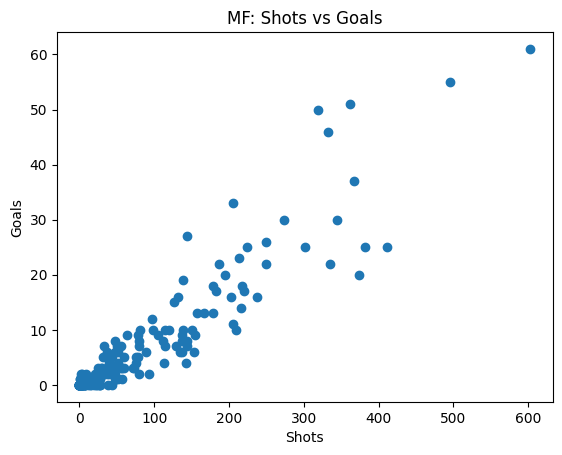

In [18]:
mid = df[df["Position"] == "Midfielder"]

plt.scatter(mid["Shots"], mid["Goals"])

plt.xlabel("Shots")
plt.ylabel("Goals")
plt.title("MF: Shots vs Goals")

plt.show()

In [19]:
fw = df[df["Position"] == "Forward"]
mid = df[df["Position"] == "Midfielder"]
defe=df[df["Position"]=="Defender"]

In [20]:
fw[["Shots","Goals"]].corr()

,Shots,Goals
Shots,1.000000,0.959289
Goals,0.959289,1.000000


In [21]:
mid[["Shots","Goals"]].corr()

,Shots,Goals
Shots,1.000000,0.923561
Goals,0.923561,1.000000


In [22]:
defe[["Shots","Goals"]].corr()

,Shots,Goals
Shots,1.000000,0.228968
Goals,0.228968,1.000000


FWとMFではシュート数とゴール数に強い正の相関が見られた。
特にFWは約0.96と非常に高く、シュート数がゴール数に大きく関係していると考えられる。

一方でDFでは相関が低く、シュート数とゴール数の関係はあまり見られなかった。
これはDFが主に守備を役割としているためだと考えられる。

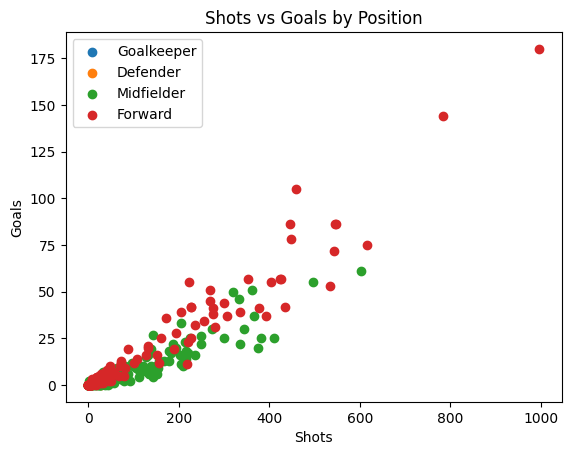

In [23]:
positions = df["Position"].unique()

for pos in positions:
    temp = df[df["Position"] == pos]

    plt.scatter(temp["Shots"], temp["Goals"], label=pos)

plt.xlabel("Shots")
plt.ylabel("Goals")
plt.title("Shots vs Goals by Position")

plt.legend()
plt.show()

In [24]:
df["finishing"] = df["Goals"] / df["Shots"]

df[["Name","Position","Goals","Shots","finishing"]].sort_values(
    by="finishing",
    ascending=False
).head(30)

,Name,Position,Goals,Shots,finishing
245,Mateusz Klich,Midfielder,2,2.0,1.000000
373,Donny van de Beek,Midfielder,1,1.0,1.000000
401,Henri Saivet,Midfielder,1,1.0,1.000000
398,Matthew Longstaff,Midfielder,2,4.0,0.500000
490,Steven Bergwijn,Forward,3,9.0,0.333333
247,Jack Harrison,Midfielder,1,3.0,0.333333
191,James Rodríguez,Midfielder,1,4.0,0.250000
516,Matheus Pereira,Forward,1,4.0,0.250000
28,Gabriel Martinelli,Forward,3,12.0,0.250000
24,Pierre-Emerick Aubameyang,Forward,55,222.0,0.247748


In [25]:
df["finishing"] = df["Goals"] / df["Shots"]

df[["Name","Position","Goals","Shots","finishing"]].sort_values(
    by="finishing",
    ascending=False
).head(30)

,Name,Position,Goals,Shots,finishing
245,Mateusz Klich,Midfielder,2,2.0,1.000000
373,Donny van de Beek,Midfielder,1,1.0,1.000000
401,Henri Saivet,Midfielder,1,1.0,1.000000
398,Matthew Longstaff,Midfielder,2,4.0,0.500000
490,Steven Bergwijn,Forward,3,9.0,0.333333
247,Jack Harrison,Midfielder,1,3.0,0.333333
191,James Rodríguez,Midfielder,1,4.0,0.250000
516,Matheus Pereira,Forward,1,4.0,0.250000
28,Gabriel Martinelli,Forward,3,12.0,0.250000
24,Pierre-Emerick Aubameyang,Forward,55,222.0,0.247748


トップ30のほとんどがシュート10本以下であり、決定力がランキングに反映されているわけではない


In [26]:
high_shots = df[df["Shots"] >= 30]

high_shots[["Name","Position","Goals","Shots","finishing"]].sort_values(
    by="finishing",
    ascending=False
).head(20)

,Name,Position,Goals,Shots,finishing
24,Pierre-Emerick Aubameyang,Forward,55,222.0,0.247748
281,Jamie Vardy,Forward,105,458.0,0.229258
317,Divock Origi,Forward,19,89.0,0.213483
129,Jorginho,Midfielder,7,33.0,0.212121
111,Chris Wood,Forward,36,172.0,0.209302
377,Mason Greenwood,Forward,10,49.0,0.204082
313,Sadio Mané,Forward,86,445.0,0.193258
23,Alexandre Lacazette,Forward,39,204.0,0.191176
282,Islam Slimani,Forward,8,42.0,0.190476
374,Anthony Martial,Forward,51,268.0,0.190299


In [27]:
df.groupby("Position")["finishing"].mean()

,finishing
Position,
Defender,0.016667
Forward,0.124871
Goalkeeper,NaN
Midfielder,0.088179


In [28]:
df.sort_values(by="Goals",ascending=False).head(10)

,Name,Jersey Number,Club,Position,Nationality,Age,Appearances,Wins,Losses,Goals,...,Catches,Sweeper clearances,Throw outs,Goal Kicks,Yellow cards,Red cards,Fouls,Offsides,shots_bin,finishing
344,Sergio Agüero,10.0,Manchester-City,Forward,Argentina,32.0,263,177,44,180,...,NaN,NaN,NaN,NaN,23,1,167,194.0,"(796.8, 996.0]",0.180723
489,Harry Kane,10.0,Tottenham-Hotspur,Forward,England,27.0,212,120,48,144,...,NaN,NaN,NaN,NaN,26,0,208,160.0,"(597.6, 796.8]",0.183908
281,Jamie Vardy,9.0,Leicester-City,Forward,England,33.0,213,86,77,105,...,NaN,NaN,NaN,NaN,20,3,179,195.0,"(398.4, 597.6]",0.229258
342,Raheem Sterling,7.0,Manchester-City,Forward,England,25.0,260,161,55,86,...,NaN,NaN,NaN,NaN,28,1,297,95.0,"(398.4, 597.6]",0.157798
313,Sadio Mané,10.0,Liverpool,Forward,Senegal,28.0,196,121,35,86,...,NaN,NaN,NaN,NaN,21,3,215,117.0,"(398.4, 597.6]",0.193258
140,Olivier Giroud,18.0,Chelsea,Forward,France,33.0,238,133,56,86,...,NaN,NaN,NaN,NaN,18,2,223,120.0,"(398.4, 597.6]",0.156934
314,Mohamed Salah,11.0,Liverpool,Forward,Egypt,28.0,123,90,12,78,...,NaN,NaN,NaN,NaN,4,0,63,65.0,"(398.4, 597.6]",0.173719
198,Theo Walcott,11.0,Everton,Forward,England,31.0,346,176,93,75,...,NaN,NaN,NaN,NaN,10,0,101,163.0,"(597.6, 796.8]",0.121753
169,Christian Benteke,17.0,Crystal-Palace,Forward,Belgium,29.0,225,73,107,72,...,NaN,NaN,NaN,NaN,35,3,357,203.0,"(398.4, 597.6]",0.132353
185,Gylfi Sigurdsson,10.0,Everton,Midfielder,Iceland,31.0,284,114,110,61,...,NaN,NaN,NaN,NaN,20,0,193,16.0,"(597.6, 796.8]",0.101161


In [29]:
df["finishing"]=df["Goals"]/df["Shots"]
df.sort_values(by="finishing",ascending=False).head(10)

,Name,Jersey Number,Club,Position,Nationality,Age,Appearances,Wins,Losses,Goals,...,Catches,Sweeper clearances,Throw outs,Goal Kicks,Yellow cards,Red cards,Fouls,Offsides,shots_bin,finishing
245,Mateusz Klich,43.0,Leeds-United,Midfielder,Poland,30.0,2,1,1,2,...,NaN,NaN,NaN,NaN,1,0,5,1.0,"(-0.996, 199.2]",1.000000
373,Donny van de Beek,34.0,Manchester-United,Midfielder,Netherlands,23.0,1,0,1,1,...,NaN,NaN,NaN,NaN,0,0,0,0.0,"(-0.996, 199.2]",1.000000
401,Henri Saivet,28.0,Newcastle-United,Midfielder,Senegal,29.0,5,3,2,1,...,NaN,NaN,NaN,NaN,0,0,1,0.0,"(-0.996, 199.2]",1.000000
398,Matthew Longstaff,4.0,Newcastle-United,Midfielder,England,20.0,9,2,4,2,...,NaN,NaN,NaN,NaN,1,0,6,0.0,"(-0.996, 199.2]",0.500000
490,Steven Bergwijn,23.0,Tottenham-Hotspur,Forward,Netherlands,22.0,16,8,4,3,...,NaN,NaN,NaN,NaN,2,0,9,0.0,"(-0.996, 199.2]",0.333333
247,Jack Harrison,22.0,Leeds-United,Midfielder,England,23.0,2,1,1,1,...,NaN,NaN,NaN,NaN,0,0,1,3.0,"(-0.996, 199.2]",0.333333
191,James Rodríguez,19.0,Everton,Midfielder,Colombia,29.0,2,2,0,1,...,NaN,NaN,NaN,NaN,0,0,1,0.0,"(-0.996, 199.2]",0.250000
516,Matheus Pereira,12.0,West-Bromwich-Albion,Forward,Brazil,24.0,2,0,2,1,...,NaN,NaN,NaN,NaN,0,0,3,0.0,"(-0.996, 199.2]",0.250000
28,Gabriel Martinelli,35.0,Arsenal,Forward,Brazil,19.0,14,3,3,3,...,NaN,NaN,NaN,NaN,1,0,9,2.0,"(-0.996, 199.2]",0.250000
24,Pierre-Emerick Aubameyang,14.0,Arsenal,Forward,Gabon,31.0,87,43,25,55,...,NaN,NaN,NaN,NaN,4,1,30,55.0,"(199.2, 398.4]",0.247748


In [30]:
high_shots=df[df["Shots"]>30]
high_shots[["Name","Position","Shots","Goals","finishing"]].sort_values(by="finishing",ascending=False).head(10)

,Name,Position,Shots,Goals,finishing
24,Pierre-Emerick Aubameyang,Forward,222.0,55,0.247748
281,Jamie Vardy,Forward,458.0,105,0.229258
317,Divock Origi,Forward,89.0,19,0.213483
129,Jorginho,Midfielder,33.0,7,0.212121
111,Chris Wood,Forward,172.0,36,0.209302
377,Mason Greenwood,Forward,49.0,10,0.204082
313,Sadio Mané,Forward,445.0,86,0.193258
23,Alexandre Lacazette,Forward,204.0,39,0.191176
282,Islam Slimani,Forward,42.0,8,0.190476
374,Anthony Martial,Forward,268.0,51,0.190299


フォワードが多い
極端な値はなく一番の24番の人はシュートの数も200を超えていて一番決定力があるといってもいい


In [31]:
df.groupby("Position")["finishing"].mean()

,finishing
Position,
Defender,0.016667
Forward,0.124871
Goalkeeper,NaN
Midfielder,0.088179


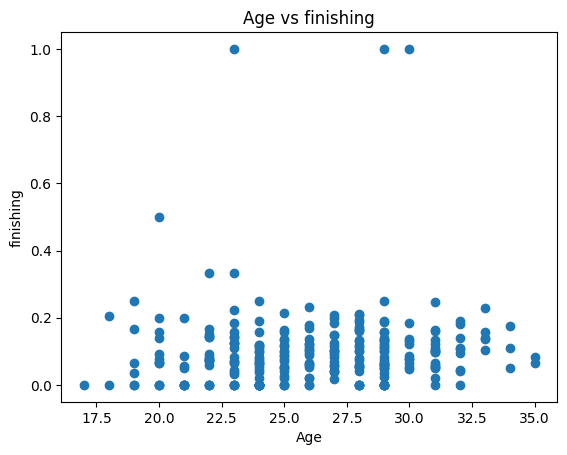

In [32]:
plt.scatter(df["Age"],df["finishing"])
plt.xlabel("Age")
plt.ylabel("finishing")
plt.title("Age vs finishing")
plt.show()

飛びぬけて決定力が高い人は20
代後半に2人、23歳くらいに1人いる
年齢はあまり相関がない

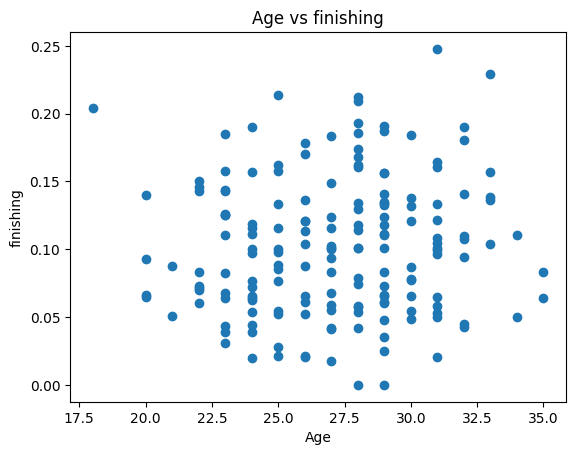

In [33]:
plt.scatter(high_shots["Age"],high_shots["finishing"])
plt.xlabel("Age")
plt.ylabel("finishing")
plt.title("Age vs finishing")
plt.show()

In [34]:
high_shots[["Age","finishing"]].corr()

,Age,finishing
Age,1.00000,0.07949
finishing,0.07949,1.00000


シュート数が多い人のみにするとある程度相関がある

<Axes: xlabel='Position'>

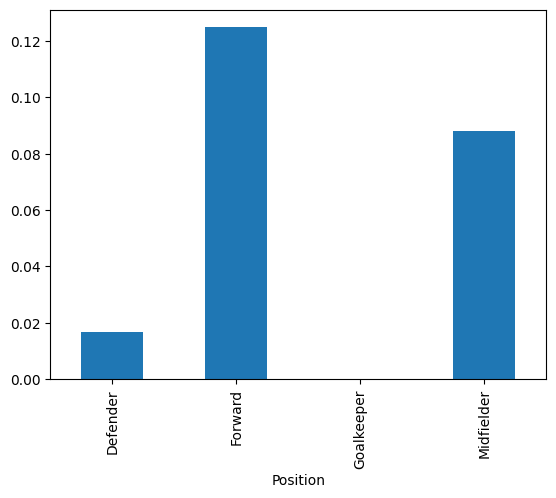

In [35]:
df.groupby("Position")["finishing"].mean().plot(kind="bar")

フォワードは単純にゴールからの距離が近く、シュートが決まりやすい可能性がある
また、ゴールすることが役割の一つであることから決定力が高い

In [36]:
df["age_bin"]=pd.cut(df["Age"],bins=[15,20,25,30,35,40],labels=["15-20","20-25","25-30","30-35","35-40"])

In [37]:
df.groupby("age_bin")["finishing"].mean()

/tmp/ipykernel_9767/4065900263.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_bin")["finishing"].mean()


,finishing
age_bin,
15-20,0.099518
20-25,0.088854
25-30,0.111703
30-35,0.105506
35-40,NaN


/tmp/ipykernel_9767/1809268236.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_bin")["finishing"].mean().plot(kind="bar")


<Axes: xlabel='age_bin'>

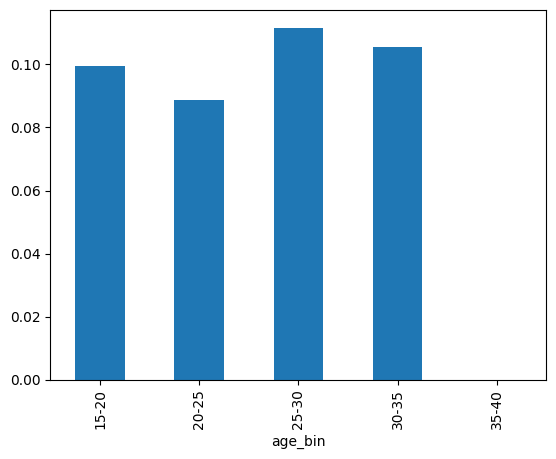

In [38]:
df.groupby("age_bin")["finishing"].mean().plot(kind="bar")

決定力はそこまで差がなく、年齢との関係はそこまでないと考えられる

考察
分析の結果から、フォワードはゴールとの距離が近く、ゴールを奪う役割であることから、決定力が高く、これはシュート数との相関が見られたが、年齢との相関は見られなかった。